<a href="https://colab.research.google.com/github/Melisaoktavia/pratikum_minggu-5/blob/main/PCD_MGG5_P3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRAKTIKUM 5.3


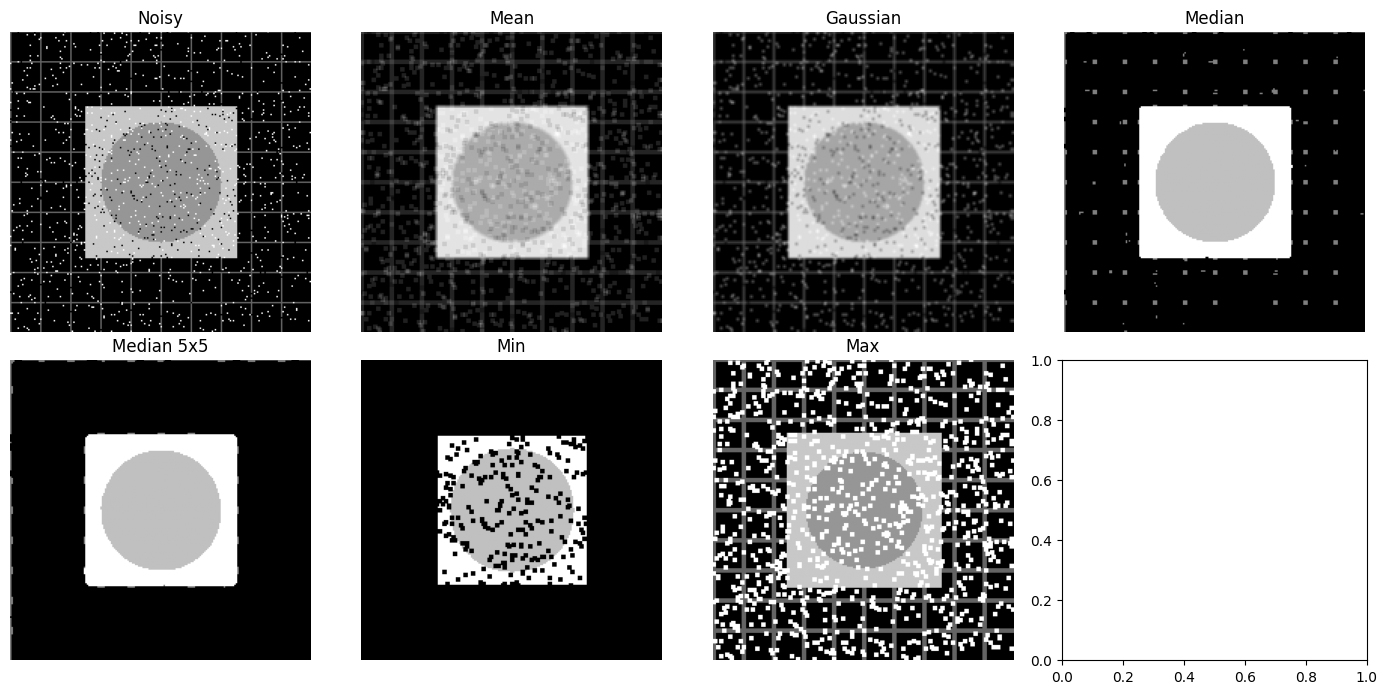

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("PRAKTIKUM 5.3")

clean_img = np.zeros((200,200),dtype=np.uint8)

for i in range(0,200,20):
    cv2.line(clean_img,(i,0),(i,199),100,1)
    cv2.line(clean_img,(0,i),(199,i),100,1)

cv2.rectangle(clean_img,(50,50),(150,150),200,-1)
cv2.circle(clean_img,(100,100),40,150,-1)

def add_salt_pepper(image, prob=0.05):

    noisy=image.copy()

    salt=np.random.rand(*image.shape)<prob/2
    pepper=np.random.rand(*image.shape)<prob/2

    noisy[salt]=255
    noisy[pepper]=0

    return noisy

noisy_img = add_salt_pepper(clean_img)

filters={

    'Noisy':lambda x:x,
    'Mean':lambda x:cv2.blur(x,(3,3)),
    'Gaussian':lambda x:cv2.GaussianBlur(x,(3,3),0),
    'Median':lambda x:cv2.medianBlur(x,3),
    'Median 5x5':lambda x:cv2.medianBlur(x,5),
    'Min':lambda x:cv2.erode(x,np.ones((3,3),np.uint8)),
    'Max':lambda x:cv2.dilate(x,np.ones((3,3),np.uint8))

}

fig,axes=plt.subplots(2,4,figsize=(14,7))
axes=axes.ravel()

for i,(name,f) in enumerate(filters.items()):

    img=f(noisy_img)

    axes[i].imshow(img,cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()